# Разведочный анализ данных: Give Me Some Credit

**Цель**: первичное знакомство с датасетом, оценка качества данных, формулировка гипотез для предобработки.

**Датасет**: `cs-training.csv` (Kaggle: Give Me Some Credit)
- Объём: ~150 000 записей
- Признаки: 10 числовых + 1 целевая
- Задача: бинарная классификация (дефолт заёмщика)

In [3]:
import sys
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.api.types import is_integer_dtype, is_float_dtype

# Добавление корня проекта в sys.path для импорта модулей src/
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Импорт из модулей проекта
from src.data.loader import load_data

# Настройки визуализации
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

logger.info("Окружение настроено. Версия pandas: %s", pd.__version__)

16:44:39 | INFO     | __main__ | Окружение настроено. Версия pandas: 2.2.2


In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_FILE = "cs-training.csv"
# Целевая переменная
TARGET_COL = "SeriousDlqin2yrs"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "eda"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ARTIFACTS_DATA_DIR = ARTIFACTS_DIR / "data"
ARTIFACTS_DATA_DIR.mkdir(exist_ok=True)

# Загрузка через модуль проекта (валидация схемы + логирование)
df = load_data(DATA_DIR, TRAIN_FILE)

# Базовая информация о датасете
logger.info("Данные загружены успешно")
logger.info("Форма датасета: %d строк × %d столбцов", *df.shape)
logger.info("Объём в памяти: %.2f МБ", df.memory_usage(deep=True).sum() / 1024**2)

df.head()

16:44:39 | INFO     | src.data.loader | Loading raw data from C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\data\raw\cs-training.csv
16:44:39 | WARNING  | src.data.loader | Filtered out 1 rows with invalid age (<18 or >120). Remaining: 149999 rows
16:44:39 | INFO     | src.data.loader | Dataset loaded: 149999 rows, 11 columns. Target distribution: {0: 0.933, 1: 0.067}
16:44:39 | INFO     | src.data.validator | Schema validation passed successfully.
16:44:39 | INFO     | __main__ | Данные загружены успешно
16:44:39 | INFO     | __main__ | Форма датасета: 149999 строк × 11 столбцов
16:44:39 | INFO     | __main__ | Объём в памяти: 15.31 МБ


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
2,0,0.957151,40,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
3,0,0.65818,38,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
4,0,0.23381,30,0.0,0.03605,3300.0,5.0,0.0,0.0,0.0,0.0
5,0,0.907239,49,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0


In [5]:
print("Информация о датасете:")
df.info(show_counts=True)

# Статистика по типам данных
print("\nРаспределение типов данных:")
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} признаков")

# Проверка уникальных значений в целевой переменной
print(f"\nУникальные значения в '{TARGET_COL}': {df[TARGET_COL].unique()}")

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
Index: 149999 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149999 non-null  Int64  
 1   RevolvingUtilizationOfUnsecuredLines  149999 non-null  Float64
 2   age                                   149999 non-null  Int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149999 non-null  Float64
 4   DebtRatio                             149999 non-null  Float64
 5   MonthlyIncome                         120268 non-null  Float64
 6   NumberOfOpenCreditLinesAndLoans       149999 non-null  Float64
 7   NumberOfTimes90DaysLate               149999 non-null  Float64
 8   NumberRealEstateLoansOrLines          149999 non-null  Float64
 9   NumberOfTime60-89DaysPastDueNotWorse  149999 non-null  Float64
 10  NumberOfDependents                    146075 non-n

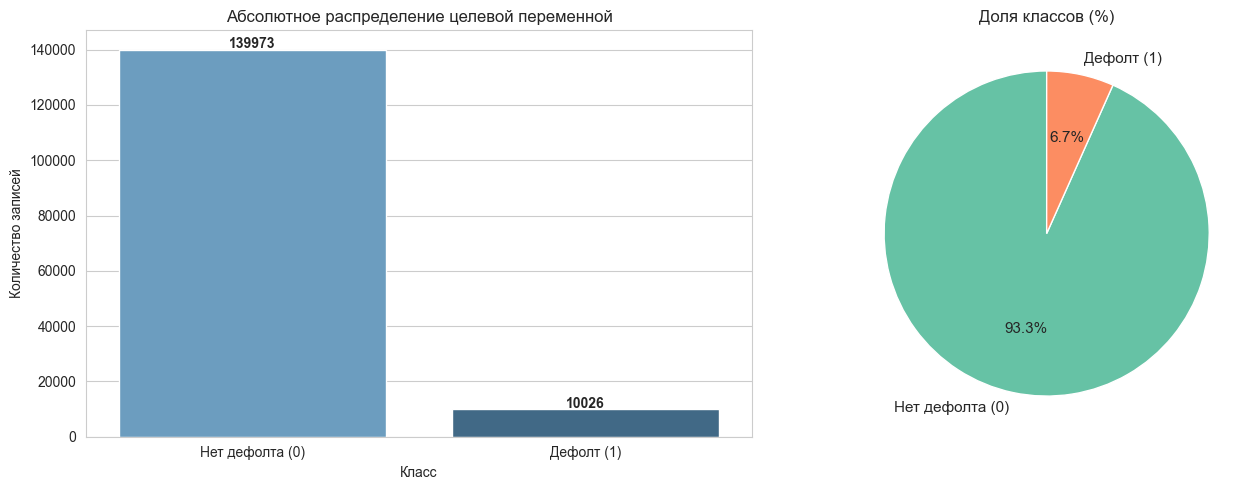

16:44:40 | INFO     | __main__ | Целевая переменная:
16:44:40 | INFO     | __main__ | Класс 0 (нет дефолта): 139973 (93.32%)
16:44:40 | INFO     | __main__ | Класс 1 (дефолт): 10026 (6.68%)
16:44:40 | INFO     | __main__ | Коэффициент дисбаланса (0:1): 13.96:1



Вывод: Датасет имеет сильный класс-дисбаланс (~14:1).
Это потребует использования class_weight='balanced' или техник ресемплинга.


In [6]:
# Распределение целевой переменной
target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

x_labels = ["Нет дефолта (0)", "Дефолт (1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барплот с абсолютными значениями — используем явные подписи
sns.barplot(x=x_labels, y=target_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Абсолютное распределение целевой переменной")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество записей")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha="center", fontweight="bold")

# Круговая диаграмма с процентами
axes[1].pie(
    target_pct.values,
    labels=x_labels,
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
    textprops={"fontsize": 11}
)
axes[1].set_title("Доля классов (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Логирование метрик дисбаланса
imbalance_ratio = target_counts[0] / target_counts[1]
logger.info("Целевая переменная:")
logger.info("Класс 0 (нет дефолта): %d (%.2f%%)", target_counts[0], target_pct[0])
logger.info("Класс 1 (дефолт): %d (%.2f%%)", target_counts[1], target_pct[1])
logger.info("Коэффициент дисбаланса (0:1): %.2f:1", imbalance_ratio)

# Вывод для отчёта
print(f"\nВывод: Датасет имеет сильный класс-дисбаланс (~{imbalance_ratio:.0f}:1).")
print("Это потребует использования class_weight='balanced' или техник ресемплинга.")

16:44:40 | INFO     | __main__ | Обнаружены пропущенные значения в 2 признаках:
16:44:40 | INFO     | __main__ | MonthlyIncome: 29731 пропусков (19.82%)
16:44:40 | INFO     | __main__ | NumberOfDependents: 3924 пропусков (2.62%)


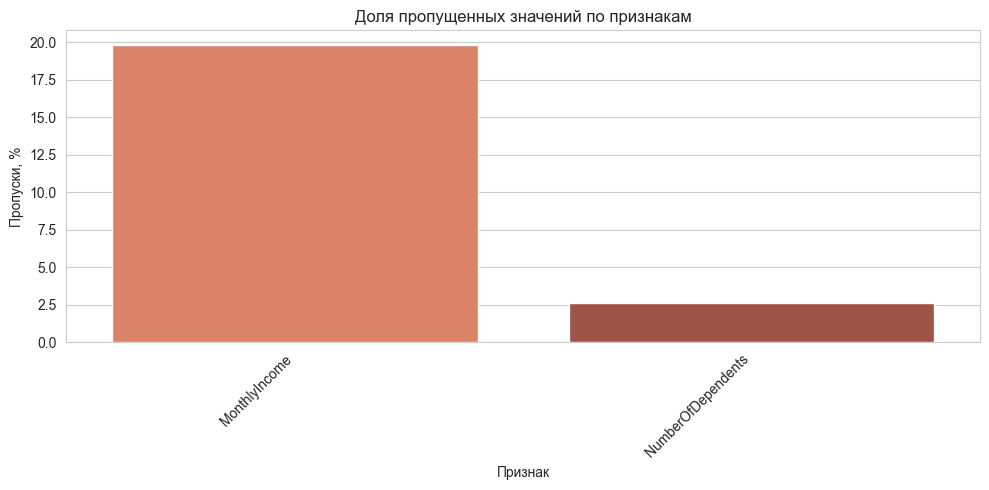


Вывод: Признаки 'MonthlyIncome' и 'NumberOfDependents' требуют импутации.
Рекомендация: медиана для числовых признаков с выбросами, мода для категориальных.


In [7]:
# Статистика пропусков
missing_stats = df.isnull().sum()
missing_pct = (missing_stats / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing_stats,
    "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

if not missing_df.empty:
    logger.info("Обнаружены пропущенные значения в %d признаках:", len(missing_df))
    for col, row in missing_df.iterrows():
        logger.info("%s: %d пропусков (%.2f%%)", col, int(row["missing_count"]), row["missing_pct"])
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y=missing_df["missing_pct"], palette="OrRd_d")
    plt.title("Доля пропущенных значений по признакам")
    plt.xlabel("Признак")
    plt.ylabel("Пропуски, %")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_missing_values.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    logger.info("Пропущенные значения не обнаружены")

if not missing_df.empty:
    print(f"\nВывод: Признаки '{missing_df.index[0]}' и '{missing_df.index[1]}' требуют импутации.")
    print("Рекомендация: медиана для числовых признаков с выбросами, мода для категориальных.")

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL)

print("Описательная статистика числовых признаков:")
print("-" * 80)
stats_df = df[numeric_cols].describe().T
stats_df["skewness"] = df[numeric_cols].skew().round(3)
stats_df["null_count"] = df[numeric_cols].isnull().sum()
print(stats_df[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "null_count"]])

# Выделение признаков с экстремальным перекосом
high_skew = stats_df[abs(stats_df["skewness"]) > 2].index.tolist()
if high_skew:
    logger.warning("Признаки с сильным перекосом (|skew| > 2): %s", high_skew)
    print(f"\nВывод: Признаки {high_skew} могут потребовать лог-трансформации или winsorization.")

16:44:41 | WARNING  | __main__ | Признаки с сильным перекосом (|skew| > 2): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse']


Описательная статистика числовых признаков:
--------------------------------------------------------------------------------
                                         count        mean           std  \
RevolvingUtilizationOfUnsecuredLines  149999.0    6.048472    249.756203   
age                                   149999.0   52.295555     14.771298   
NumberOfTime30-59DaysPastDueNotWorse  149999.0    0.421029      4.192795   
DebtRatio                             149999.0  353.007426   2037.825113   
MonthlyIncome                         120268.0  6670.22681  14384.733888   
NumberOfOpenCreditLinesAndLoans       149999.0    8.452776      5.145964   
NumberOfTimes90DaysLate               149999.0    0.265975      4.169318   
NumberRealEstateLoansOrLines          149999.0    1.018233      1.129772   
NumberOfTime60-89DaysPastDueNotWorse  149999.0    0.240388      4.155193   
NumberOfDependents                    146075.0    0.757214      1.115085   

                                      

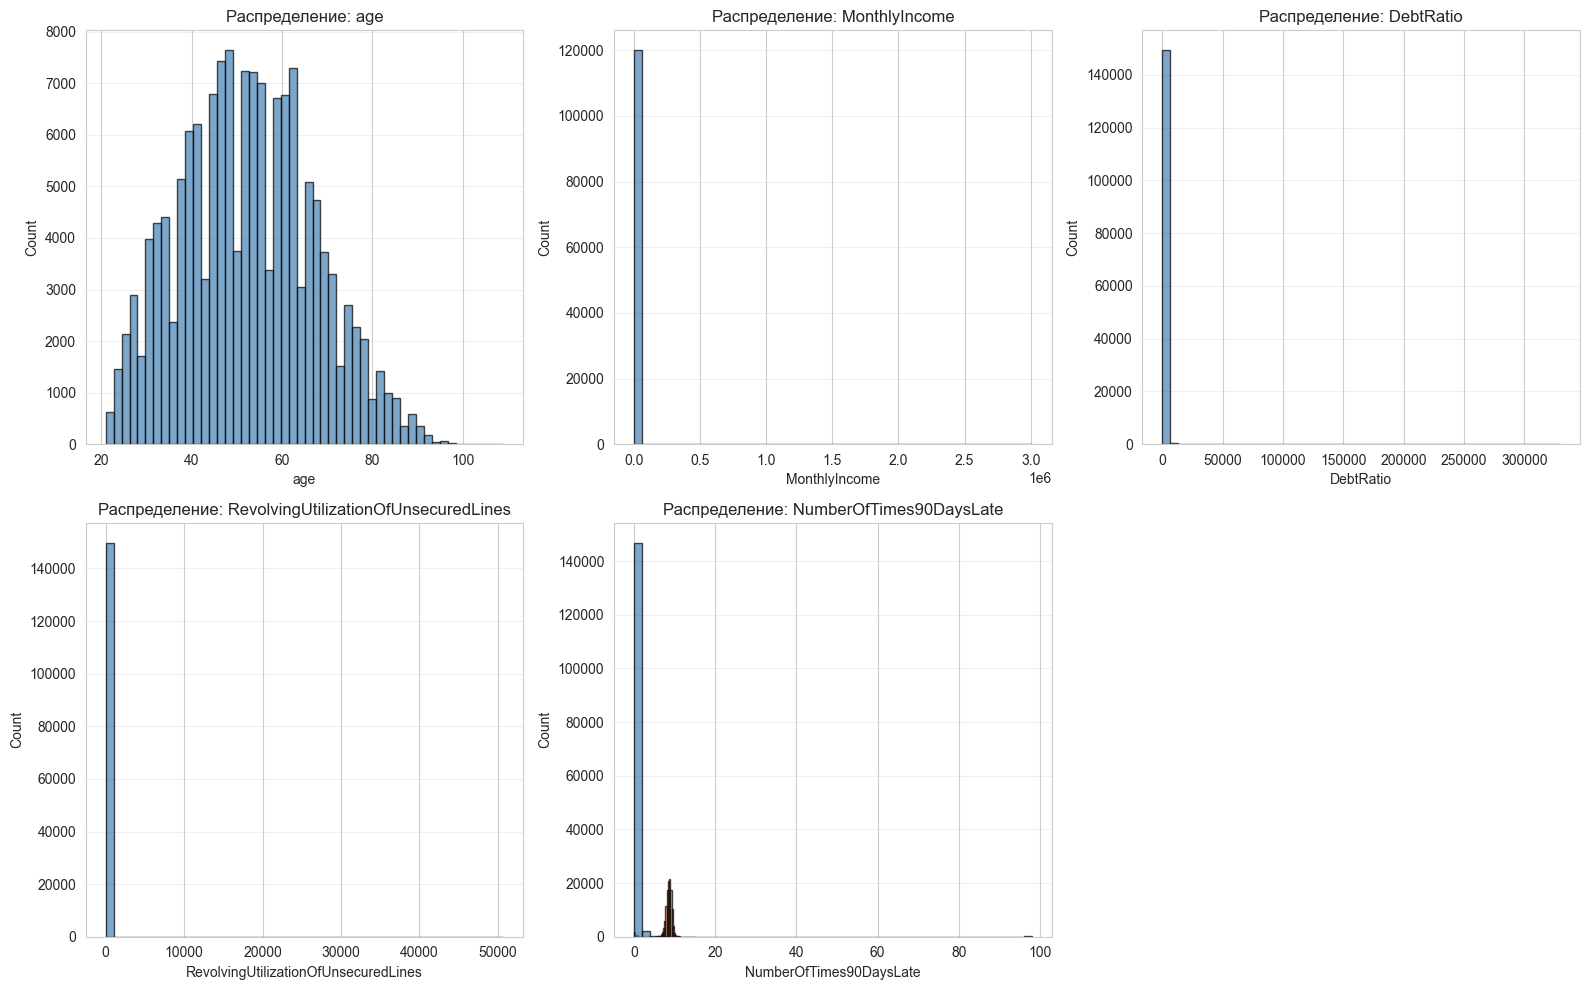

16:44:44 | INFO     | __main__ | Визуализации распределений построены


In [9]:
# Признаки для детального анализа
key_features = [
    "age",
    "MonthlyIncome", 
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfTimes90DaysLate"
]

# Фильтрация существующих признаков
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(key_features):
    data = df[col].dropna()
    ax = axes[idx]
    
    # Гистограмма
    ax.hist(data, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"Распределение: {col}")
    ax.grid(axis="y", alpha=0.3)
    
    # Лог-трансформация для признаков с длинным хвостом
    if data.max() / (data.median() + 1e-6) > 100:
        ax2 = axes[idx + 3] if idx + 3 < len(axes) else None
        if ax2:
            ax2.hist(np.log1p(data), bins=50, edgecolor="black", alpha=0.7, color="coral")
            ax2.set_xlabel(f"{col} (log-transformed)")
            ax2.set_ylabel("Count")
            ax2.set_title(f"Лог-распределение: {col}")
            ax2.grid(axis="y", alpha=0.3)

# Скрыть пустые подплоты
for idx in range(len(key_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

logger.info("Визуализации распределений построены")

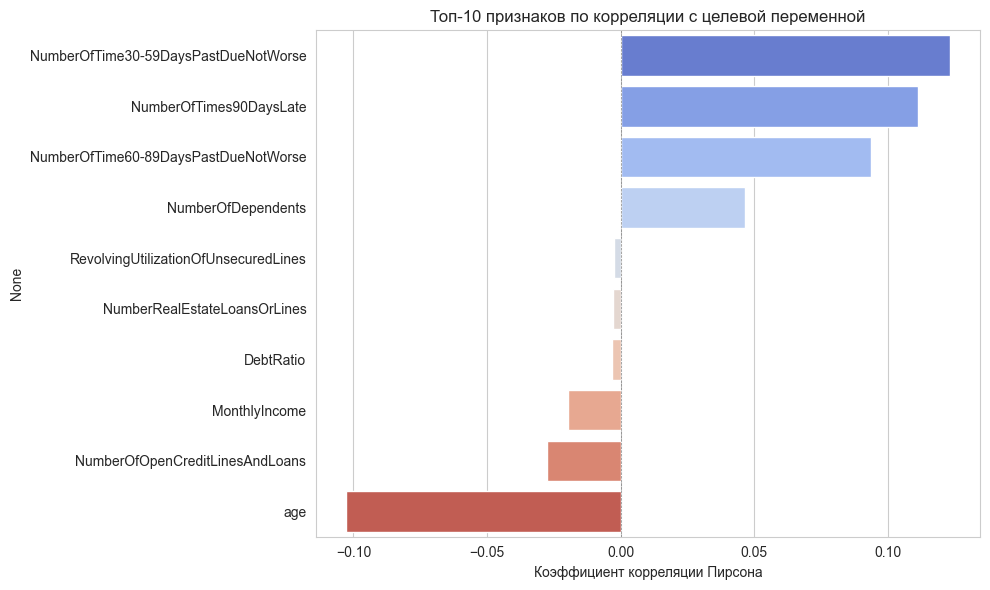

16:44:44 | INFO     | __main__ | Топ-5 признаков по корреляции с SeriousDlqin2yrs:
16:44:44 | INFO     | __main__ | NumberOfTime30-59DaysPastDueNotWorse: 0.1232
16:44:44 | INFO     | __main__ | NumberOfTimes90DaysLate: 0.1111
16:44:44 | INFO     | __main__ | NumberOfTime60-89DaysPastDueNotWorse: 0.0938
16:44:44 | INFO     | __main__ | NumberOfDependents: 0.0467
16:44:44 | INFO     | __main__ | RevolvingUtilizationOfUnsecuredLines: -0.0024


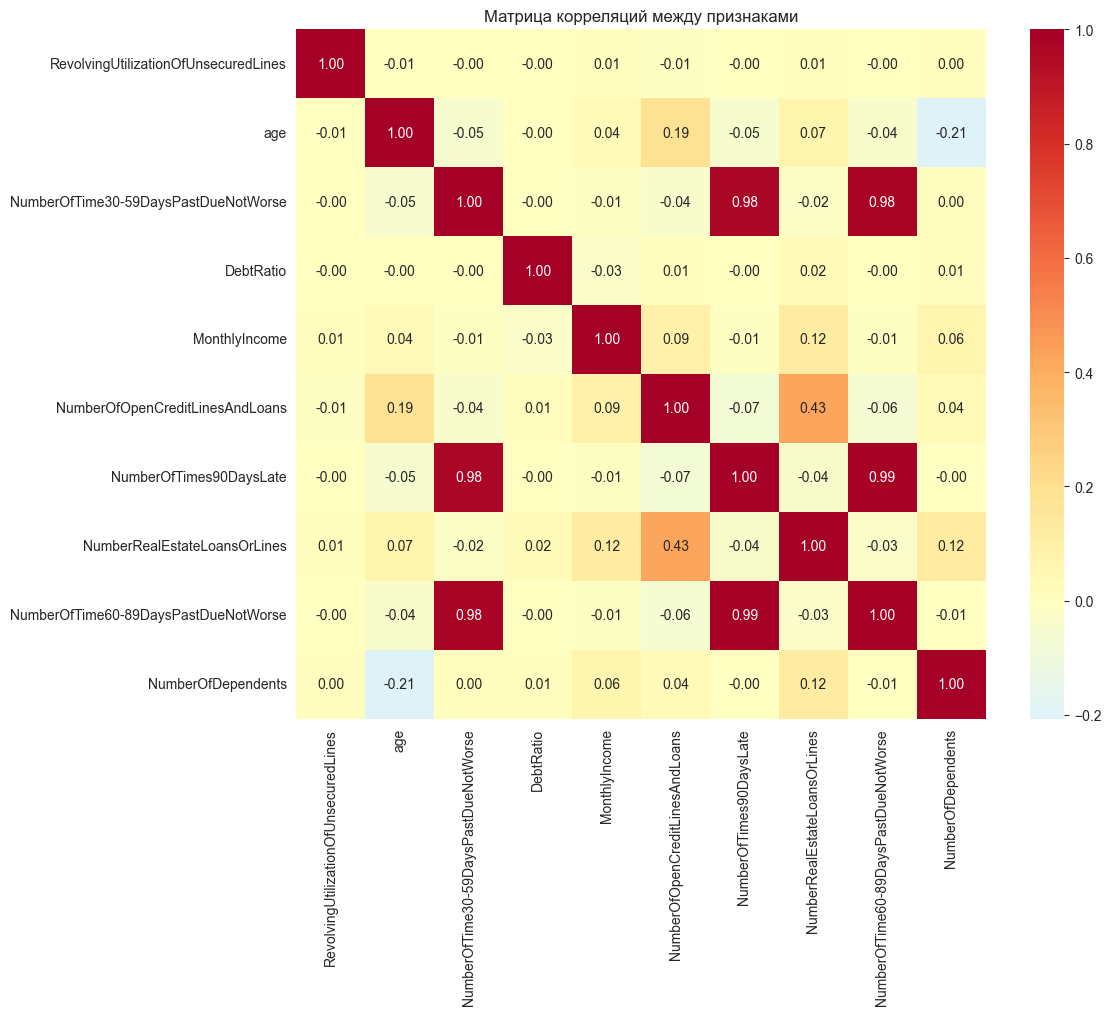

16:44:45 | WARNING  | __main__ | Обнаружены признаки с высокой корреляцией (|r| > 0.8):
16:44:45 | WARNING  | __main__ | NumberOfTime30-59DaysPastDueNotWorse <-> NumberOfTimes90DaysLate: 0.975
16:44:45 | WARNING  | __main__ | NumberOfTime30-59DaysPastDueNotWorse <-> NumberOfTime60-89DaysPastDueNotWorse: 0.980
16:44:45 | WARNING  | __main__ | NumberOfTimes90DaysLate <-> NumberOfTime60-89DaysPastDueNotWorse: 0.989



Вывод: Возможна мультиколлинеарность. Рассмотрите отбор признаков или PCA.


In [10]:
# Подготовка данных для корреляции (удаление пропусков)
df_corr = df.dropna(subset=numeric_cols)

# Расчёт корреляций Пирсона с целевой переменной
correlations = df_corr[numeric_cols].corrwith(df_corr[TARGET_COL]).sort_values(ascending=False)

# Визуализация топ-10 корреляций
plt.figure(figsize=(10, 6))
top_corr = correlations.head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
plt.title("Топ-10 признаков по корреляции с целевой переменной")
plt.xlabel("Коэффициент корреляции Пирсона")
plt.axvline(x=0, color="gray", linestyle="--", linewidth=0.5)
plt.savefig(FIGURES_DIR / "04_target_correlations.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Логирование результатов
logger.info("Топ-5 признаков по корреляции с %s:", TARGET_COL)
for feat, corr in correlations.head(5).items():
    logger.info("%s: %.4f", feat, corr)

# Матрица корреляций между признаками (тепловая карта)
plt.figure(figsize=(12, 10))
corr_matrix = df_corr[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True)
plt.title("Матрица корреляций между признаками")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# Выявление мультиколлинеарности
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    logger.warning("Обнаружены признаки с высокой корреляцией (|r| > 0.8):")
    for f1, f2, r in high_corr_pairs:
        logger.warning("%s <-> %s: %.3f", f1, f2, r)
    print(f"\nВывод: Возможна мультиколлинеарность. Рассмотрите отбор признаков или PCA.")

Анализ выбросов (метод IQR):
                             feature  outliers  outlier_pct  iqr_lower  iqr_upper
RevolvingUtilizationOfUnsecuredLines       763         0.51      -0.76       1.35
                           DebtRatio     31311        20.87      -0.86       1.91
                       MonthlyIncome      4879         4.06   -3873.50   15522.50


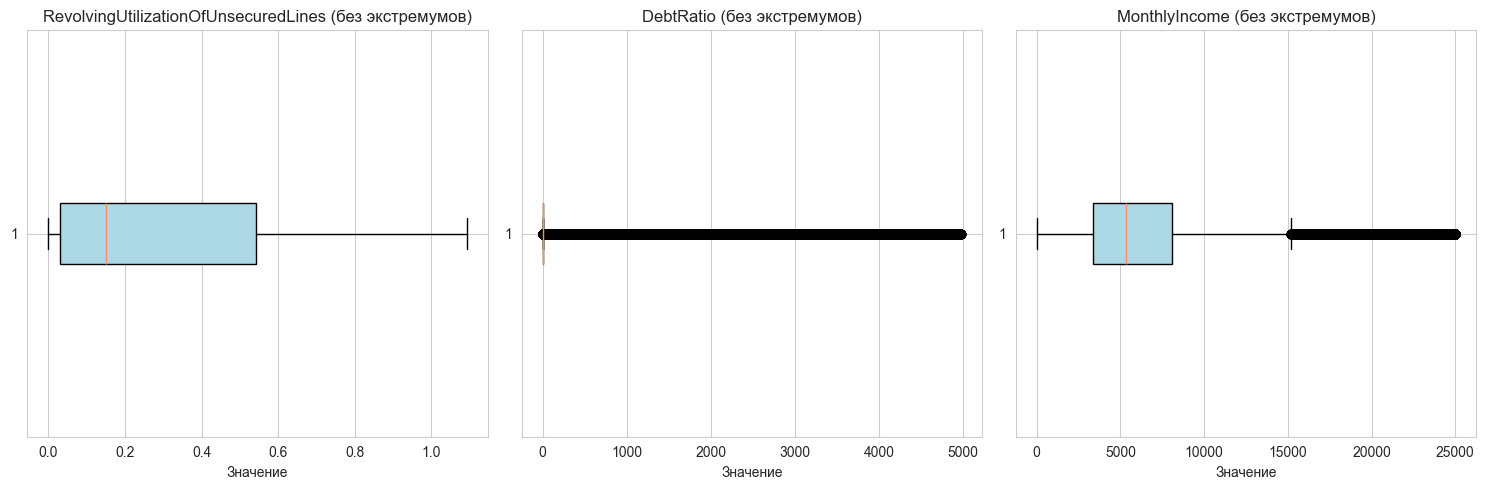

16:44:47 | INFO     | __main__ | Boxplot-визуализации построены


In [11]:
def detect_outliers_iqr(series: pd.Series) -> tuple[int, float, float, float]:
    """
    Детекция выбросов методом IQR.
    
    Returns:
        (count, lower_bound, upper_bound, outlier_pct)
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    outlier_pct = outliers / len(series) * 100
    return int(outliers), float(lower), float(upper), float(outlier_pct)

# Анализ финансовых признаков
financial_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
outlier_report = []

for col in financial_cols:
    if col in df.columns:
        clean = df[col].dropna()
        if len(clean) > 0:
            n_out, low, high, pct = detect_outliers_iqr(clean)
            outlier_report.append({
                "feature": col,
                "outliers": n_out,
                "outlier_pct": round(pct, 2),
                "iqr_lower": round(low, 2),
                "iqr_upper": round(high, 2)
            })

outlier_df = pd.DataFrame(outlier_report)
if not outlier_df.empty:
    print("Анализ выбросов (метод IQR):")
    print(outlier_df.to_string(index=False))
    
    # Визуализация через boxplot
    fig, axes = plt.subplots(1, len(financial_cols), figsize=(15, 5))
    if len(financial_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, financial_cols):
        if col in df.columns:
            data = df[col].dropna()
            # Ограничение оси для наглядности
            q99 = data.quantile(0.99)
            ax.boxplot(data[data <= q99], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
            ax.set_title(f"{col} (без экстремумов)")
            ax.set_xlabel("Значение")
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_outliers_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    logger.info("Boxplot-визуализации построены")

In [12]:
# Статистика признаков
stats_df.to_csv(ARTIFACTS_DATA_DIR / "feature_statistics.csv")
logger.info("Сохранено: %s", ARTIFACTS_DATA_DIR / "feature_statistics.csv")

# Корреляции с целевой переменной
correlations.to_frame("pearson_correlation_with_target").to_csv(ARTIFACTS_DATA_DIR / "target_correlations.csv")
logger.info("Сохранено: %s", ARTIFACTS_DATA_DIR / "target_correlations.csv")

# Отчёт о пропусках
if not missing_df.empty:
    missing_df.to_csv(ARTIFACTS_DATA_DIR / "missing_values_report.csv")
    logger.info("Сохранено: %s", ARTIFACTS_DATA_DIR / "missing_values_report.csv")

# Отчёт о выбросах
if not outlier_df.empty:
    outlier_df.to_csv(ARTIFACTS_DATA_DIR / "outliers_iqr_report.csv", index=False)
    logger.info("Сохранено: %s", ARTIFACTS_DATA_DIR / "outliers_iqr_report.csv")

# Пары с высокой корреляцией
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
    high_corr_df.to_csv(ARTIFACTS_DATA_DIR / "high_correlation_pairs.csv", index=False)
    logger.info("Сохранено: %s", ARTIFACTS_DATA_DIR / "high_correlation_pairs.csv")


16:44:47 | INFO     | __main__ | Сохранено: C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\artifacts\eda\data\feature_statistics.csv
16:44:47 | INFO     | __main__ | Сохранено: C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\artifacts\eda\data\target_correlations.csv
16:44:47 | INFO     | __main__ | Сохранено: C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\artifacts\eda\data\missing_values_report.csv
16:44:47 | INFO     | __main__ | Сохранено: C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\artifacts\eda\data\outliers_iqr_report.csv
16:44:47 | INFO     | __main__ | Сохранено: C:\Users\Fimaruyn\Desktop\GIT\rag-assistant\project\artifacts\eda\data\high_correlation_pairs.csv


# Итоговый отчёт по разведочному анализу данных (EDA)

## Описание датасета: Give Me Some Credit

### Общая характеристика

| Параметр | Значение |
|----------|----------|
| **Источник** | Kaggle: Give Me Some Credit (2011) |
| **Объём после очистки** | 149 999 записей (исключена 1 запись с возрастом >120) |
| **Количество признаков** | 10 числовых признаков + 1 целевая переменная |
| **Тип задачи** | Бинарная классификация (вероятность дефолта заёмщика) |
| **Целевая переменная** | `SeriousDlqin2yrs`: 1 = серьёзная просрочка (90+ дней) в течение 2 лет, 0 = нет |

### Описание признаков

| Признак | Тип | Описание | Бизнес-смысл |
|---------|-----|----------|--------------|
| `SeriousDlqin2yrs` | int (0/1) | Целевая переменная: наличие серьёзной просрочки | Основной прогнозный индикатор риска |
| `RevolvingUtilizationOfUnsecuredLines` | float | Отношение общего баланса по кредитным картам к сумме кредитных лимитов | Показатель кредитной нагрузки; значения >1 указывают на превышение лимита |
| `age` | int | Возраст заёмщика в годах | Демографический признак; валидный диапазон [18, 120] |
| `NumberOfTime30-59DaysPastDueNotWorse` | float | Количество просрочек платежа на 30–59 дней за последние 2 года | Индикатор дисциплины платежей |
| `DebtRatio` | float | Отношение ежемесячных долговых обязательств к ежемесячному доходу | Показатель финансовой устойчивости |
| `MonthlyIncome` | float | Ежемесячный доход заёмщика | Ключевой признак платёжеспособности; содержит пропуски |
| `NumberOfOpenCreditLinesAndLoans` | float | Количество открытых кредитных линий и займов | Показатель кредитной активности |
| `NumberOfTimes90DaysLate` | float | Количество просрочек платежа на 90+ дней за последние 2 года | Сильный предиктор дефолта |
| `NumberRealEstateLoansOrLines` | float | Количество ипотечных кредитов или линий | Показатель наличия недвижимости в залоге |
| `NumberOfTime60-89DaysPastDueNotWorse` | float | Количество просрочек платежа на 60–89 дней за последние 2 года | Промежуточный индикатор риска |
| `NumberOfDependents` | float | Количество иждивенцев заёмщика | Косвенный признак финансовой нагрузки; содержит пропуски |

---

## Ключевые результаты разведочного анализа

### 1. Распределение целевой переменной

- **Класс 0 (нет дефолта)**: 139 973 записи (93.32%)
- **Класс 1 (дефолт)**: 10 026 записей (6.68%)
- **Коэффициент дисбаланса**: ~14:1

**Вывод**: Датасет характеризуется выраженным класс-дисбалансом. Без коррекции весов модели будут склонны оптимизировать точность за счёт игнорирования миноритарного класса, что неприемлемо для задачи кредитного скоринга.

### 2. Пропущенные значения

| Признак | Количество пропусков | Доля, % | Рекомендация |
|---------|---------------------|---------|--------------|
| `MonthlyIncome` | 29 731 | 19.82% | Импутация медианой (устойчива к выбросам) |
| `NumberOfDependents` | 3 924 | 2.62% | Импутация модой или медианой |

**Вывод**: Пропуски в `MonthlyIncome` требуют системной обработки, так как признак критичен для оценки платёжеспособности. Пропуски в `NumberOfDependents` могут быть импутированы более простым способом из-за низкой доли.

### 3. Статистические характеристики числовых признаков

| Признак | Среднее | Медиана | Стандартное отклонение | Перекос (skewness) |
|---------|---------|---------|----------------------|-------------------|
| `RevolvingUtilizationOfUnsecuredLines` | 6.05 | 0.15 | 249.76 | 97.63 |
| `DebtRatio` | 353.01 | 0.37 | 2037.83 | 95.16 |
| `MonthlyIncome` | 6670.23 | 5400.00 | 14384.73 | 114.04 |
| `NumberOfTime30-59DaysPastDueNotWorse` | 0.42 | 0.00 | 4.19 | 22.60 |
| `NumberOfTimes90DaysLate` | 0.27 | 0.00 | 4.17 | 23.09 |

**Вывод**: Финансовые признаки (`RevolvingUtilization`, `DebtRatio`, `MonthlyIncome`) демонстрируют экстремальный правосторонний перекос (skewness > 95) и наличие выбросов, что требует трансформации распределения перед обучением линейных моделей.

### 4. Корреляционный анализ

**Топ-5 признаков по корреляции с целевой переменной**:
1. `NumberOfTime30-59DaysPastDueNotWorse`: 0.123
2. `NumberOfTimes90DaysLate`: 0.111
3. `NumberOfTime60-89DaysPastDueNotWorse`: 0.094
4. `NumberOfDependents`: 0.047
5. `RevolvingUtilizationOfUnsecuredLines`: -0.002

**Выявленная мультиколлинеарность** (|r| > 0.8):
- `NumberOfTime30-59DaysPastDueNotWorse` ↔ `NumberOfTime60-89DaysPastDueNotWorse`: 0.980
- `NumberOfTime30-59DaysPastDueNotWorse` ↔ `NumberOfTimes90DaysLate`: 0.975
- `NumberOfTimes90DaysLate` ↔ `NumberOfTime60-89DaysPastDueNotWorse`: 0.989

**Вывод**: Три признака, отражающие частоту просрочек различной длительности, практически линейно зависимы. Их одновременное использование может приводить к нестабильности оценок в линейных моделях и избыточности в ансамблевых методах.

### 5. Анализ выбросов (метод IQR)

| Признак | Доля выбросов, % | Нижняя граница | Верхняя граница |
|---------|-----------------|----------------|-----------------|
| `DebtRatio` | 20.87% | -0.86 | 1.91 |
| `MonthlyIncome` | 4.06% | -3873.50 | 15522.50 |
| `RevolvingUtilizationOfUnsecuredLines` | 0.51% | -0.76 | 1.35 |

**Вывод**: Признак `DebtRatio` содержит более 20% выбросов по методу межквартильного размаха, что указывает на необходимость применения устойчивых к выбросам методов масштабирования или предварительной трансформации распределения.

---

## Сформулированные гипотезы для этапа предобработки

### Гипотеза 1: Обработка пропущенных значений
- **MonthlyIncome (19.82% пропусков)**: применить импутацию медианой, вычисленной на обучающей выборке. Медиана устойчивее среднего к экстремальным значениям, характерным для распределения доходов.
- **NumberOfDependents (2.62% пропусков)**: применить импутацию модой (наиболее частое значение) или медианой. Низкая доля пропусков позволяет использовать простые методы без риска существенного смещения распределения.

### Гипотеза 2: Стабилизация распределений финансовых признаков
- **Признаки**: `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`
- **Метод**: применение логарифмического преобразования `log1p(x) = ln(1 + x)` перед масштабированием
- **Обоснование**: лог-трансформация сжимает длинный правый хвост распределения, стабилизирует дисперсию и улучшает сходимость градиентных методов оптимизации в линейных моделях. Для деревьев трансформация не обязательна, но повышает стабильность признаков при кросс-валидации.

### Гипотеза 3: Устранение мультиколлинеарности признаков просрочек
- **Признаки**: `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`
- **Метод**: создание агрегированного признака `TotalPastDue = sum(NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate)` с последующим удалением исходных трёх признаков
- **Обоснование**: агрегация сохраняет информацию о совокупной частоте просрочек, снижает размерность признакового пространства и устраняет линейную зависимость, которая может дестабилизировать оценки коэффициентов в линейных моделях.

### Гипотеза 4: Балансировка классов при обучении
- **Проблема**: соотношение классов ~14:1 в пользу недефолтов
- **Метод**: использование параметра `class_weight='balanced'` в моделях scikit-learn или стратифицированной кросс-валидации
- **Обоснование**: автоматическая балансировка весов классов позволяет модели учитывать миноритарный класс без необходимости ресемплинга, что снижает риск утечки данных при валидации.

### Гипотеза 5: Масштабирование признаков
- **Метод**: применение `RobustScaler` (масштабирование на основе медианы и межквартильного размаха) после лог-трансформации
- **Обоснование**: `RobustScaler` устойчив к выбросам, которые сохраняются даже после лог-трансформации. Масштабирование необходимо для линейных моделей с регуляризацией и методов, чувствительных к масштабу признаков (например, градиентный спуск).

---

## Артефакты

### Визуализации
- `figures/01_target_distribution.png` — распределение целевой переменной
- `figures/02_missing_values.png` — доля пропущенных значений
- `figures/03_feature_distributions.png` — распределения ключевых признаков
- `figures/04_target_correlations.png` — топ корреляций с целевой переменной
- `figures/05_correlation_matrix.png` — матрица корреляций
- `figures/06_outliers_boxplot.png` — boxplot для анализа выбросов

### Табличные данные
- `data/feature_statistics.csv` — сводная статистика по признакам
- `data/target_correlations.csv` — корреляции с целевой переменной
- `data/missing_values_report.csv` — отчёт о пропусках
- `data/outliers_iqr_report.csv` — отчёт о выбросах
- `data/high_correlation_pairs.csv` — пары с высокой корреляцией
